# Presentation Notebook - Cosmic Rays


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import cell
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/CosmicRays')  #make sure this is your directory where your .ipynb and .py are located

from cosmic_model_final import *

Mounted at /content/drive


# Physics Questions



### 1. Testing with simple showers

As a simple test of your Monte Carlo code, __find the "shower"__ induced by an initial __electron__, initial __muon__, and initial __pion__, each traveling at __0.995c towards the ground straight down__.  (None of these will produce a complicated shower; the electron doesn't interact, and the other interactions can only happen once.)  _Set `attenuation = False` in the main loop_ for these tests.  

Make a plot or plots showing the particle trajectories, and explain them.  Once you think your plots make sense, check conservation of energy and momentum for the muon decay.

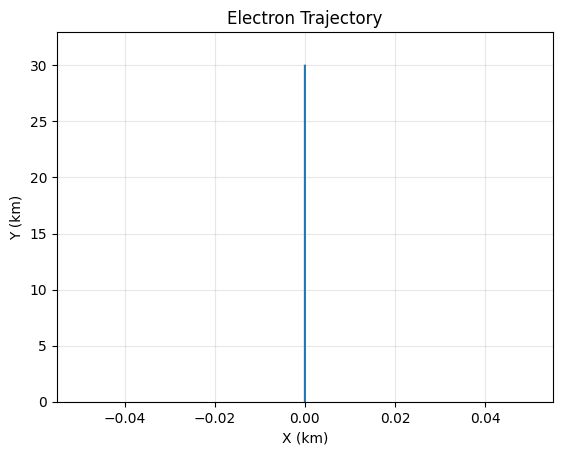

/content/drive/MyDrive/Colab Notebooks/CosmicRays/cosmic_model_final.py:219: RuntimeWarning: divide by zero encountered in scalar divide
  gamma = 1/np.sqrt(1 - (beta_magnitude)**2)


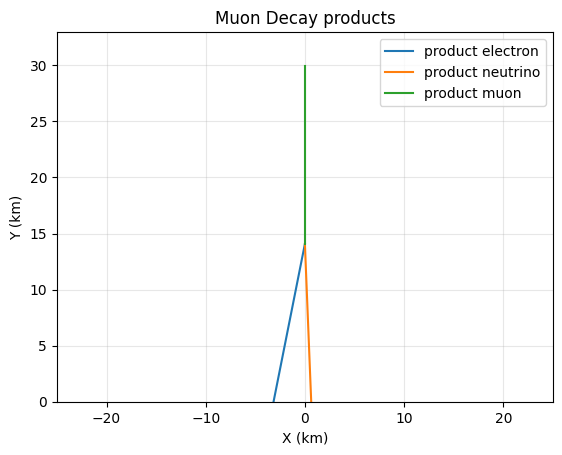

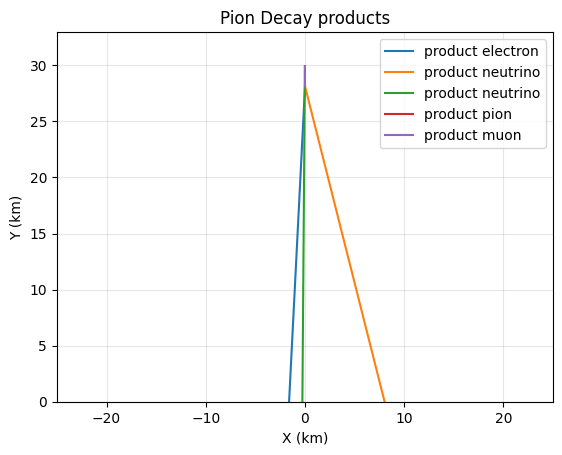

In [ ]:

%matplotlib inline
import matplotlib.pyplot as plt



#all three particles share these properties

starting_height = 30 * 1000 / 3e8
y_traj = np.array([starting_height])# same height as the main loop example usage
x_traj = np.array([0])#the particles move straight down
px=0
beta_x = 0
dt = 1e-7
Nsteps = 1500

#constructing the electron input tuple
electron_py = float(velocity_to_momentum(particle_mass('electron'), beta_x = 0, beta_y = -0.995)[1])
electron_tuple = ('electron', px, electron_py, x_traj.copy(), y_traj.copy())
#print(electron_tuple)

#constructing the muon input tuple

muon_py = float(velocity_to_momentum(particle_mass('muon'), beta_x = 0, beta_y = -0.995)[1])
muon_tuple = ('muon', px, muon_py, x_traj.copy(), y_traj.copy())
#print(muon_tuple)

#constructing the muon input tuple

pion_py = float(velocity_to_momentum(particle_mass('pion'), beta_x = 0, beta_y = -0.995)[1])
pion_tuple = ('pion', px, pion_py, x_traj.copy(), y_traj.copy())
#print(pion_tuple)




#running the main loop for each particle

#Electron case


result_electron = run_cosmic_MC([electron_tuple], dt, Nsteps, attenuation=False)
result_electron_x_traj = result_electron[0][3]
result_electron_y_traj = result_electron[0][4]


km_per_ls = 2.997e5#claude suggested this conversion

plt.plot(result_electron_x_traj * km_per_ls, result_electron_y_traj * km_per_ls)
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.ylim(0, starting_height * km_per_ls * 1.1)#claude helped change the scale of the graph
plt.title('Electron Trajectory')
plt.grid(True, alpha=0.3)
plt.show()


#Muon case


result_particles_muon_decay = run_cosmic_MC([muon_tuple], dt, Nsteps, attenuation=False)
for particle in result_particles_muon_decay:
  muon_decay_name = particle[0]
  muon_decay_x_traj = particle[3] * km_per_ls
  muon_decay_y_traj = particle[4] * km_per_ls
  plt.plot(muon_decay_x_traj, muon_decay_y_traj, label = 'product ' + muon_decay_name)


plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.xlim(-25, 25)
plt.ylim(0, starting_height * km_per_ls * 1.1)
plt.title('Muon Decay products')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#Pion case


result_particles_pion_decay = run_cosmic_MC([pion_tuple], dt, Nsteps, attenuation=False)

for particle in result_particles_pion_decay:
  pion_decay_name = particle[0]
  pion_decay_x_traj = particle[3] * km_per_ls
  pion_decay_y_traj = particle[4] * km_per_ls
  plt.plot(pion_decay_x_traj, pion_decay_y_traj, label = 'product ' + pion_decay_name)


plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.xlim(-25, 25)
plt.ylim(0, starting_height * km_per_ls * 1.1)
plt.title('Pion Decay products')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Explanation decay of Plots

##Electron decay

When we look at the electron decay plot, we see that it is a straight line from the starting height to earth's surface.  The reason for this is becuase our model only considers three particle interactions: proton downscattering, pion decay, and muon decay.  Since there are no electron interactions in our model, we should expect an electrion to pass through the atmosphere uneffected by any other particles.


##Muon decay
When a muon decays, it produces two products: an electron and a neutrino.  This decay is isotropic, meaning the daughter particles are emitted at randomly chosen angles.  In order to conserve momentum, the electorn must travel in exactly the opposite direction as the neutrino.  This explains why whenever we see the electron go right, the neutrino goes left, and vice versa.  Additionally, we notice that the neutrino often has a larger magnitude of x displacement when compared to the electron.  Although the two particles have equal and opposite momenta, they do not have equal and opposite speed.  Since the neutrino is massless, it will have a larger velocity than the electron, allowing it to travel further.    


##Pion decay
We notice that the pion decay plot is distint from the muon decay plot.  For the muon case, we notice that the muon decays at some height and produces two particles.  The pion, however, produces twice as many products as the muon case.  We can understand this discrepency once we analyze the decay products of a muon and pion.  As discussed above, when a muon decays, it produces an electron and neutrino.  Neither of these particles interact in our model.  A pion, however, decays into a muon and a nutrino.  Given enough iterations of our time step, we will see this product muon decay as well.  The decay of the product muon is responsible for the two extra particles.  Once this muon decays, we get an electron and neutrino, and our chain reaction ends since neither particle interacts in our model.

Additionally, the pion decay products are also isotropic, and decay at random angles just as the muon decays.  similar to the muon decay, the two products of pion decay must travel in opposite directions to conserve momentum.

**TESTING CONSERVATION OF ENERGY AND MOMENTUM FOR MUON DECAY**

In [ ]:
#Checking muon decay conservation of energy and momentum


electron = result_particles_muon_decay[0]
neutrino = result_particles_muon_decay[1]
muon = result_particles_muon_decay[2]


#checking momentum conservation
electron_px, electron_py = electron[1], electron[2]
neutrino_px, neutrino_py = neutrino[1], neutrino[2]
muon_px, muon_py = muon[1], muon[2]



assert np.abs((electron_px + neutrino_px)-muon_px) <=1e-4
assert np.abs((electron_py + neutrino_py)-muon_py) <=1e-4



#checking energy conservation

electron_energy = np.sqrt(electron_px**2 + electron_py**2 + particle_mass('electron')**2)
neutrino_energy = np.sqrt(neutrino_px**2 + neutrino_py**2 + particle_mass('neutrino')**2)
muon_energy = np.sqrt(muon_px**2 + muon_py**2 + particle_mass('muon')**2)

assert np.abs(((electron_energy+neutrino_energy)-muon_energy)/muon_energy) <= 1e-4

### 2. Simulating a single proton shower

Simulate a cosmic-ray shower with a __single incoming proton__ with initial velocity $(\beta_x, \beta_y) = (0.95999, -0.28)$, and starting at $(x,y) = (0, 20)$ km.  __Make a two-dimensional figure__ showing the trajectories of all particles produced in the shower, and use the figure to __explain cosmic ray showers__ at a level that a freshman physics major would understand.

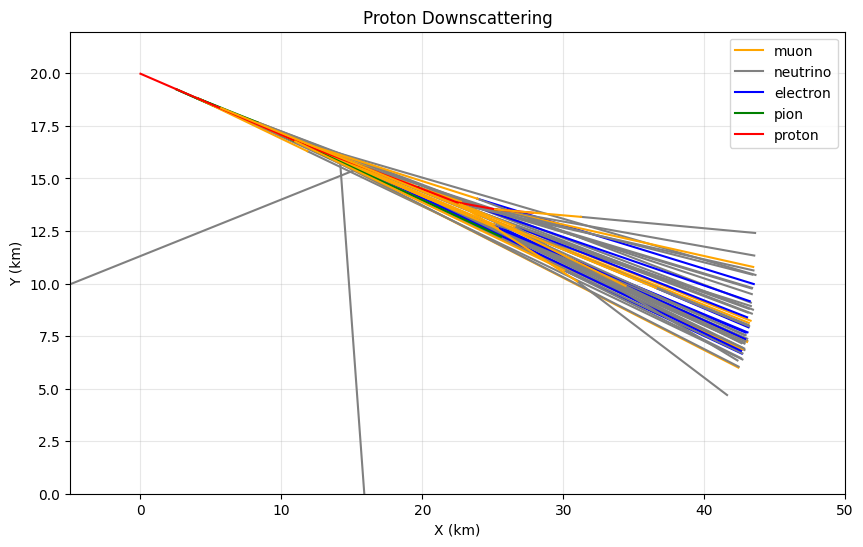

In [ ]:
starting_height = 20*1000/3e8
starting_x = 0
initial_beta_x = 0.95999
initial_beta_y = -0.28

y_traj = np.array([starting_height])
x_traj = np.array([starting_x])
proton_px, proton_py = velocity_to_momentum(particle_mass('proton'), initial_beta_x, initial_beta_y)
proton_tuple = ('proton', proton_px, proton_py, x_traj, y_traj)

result_particles = run_cosmic_MC([proton_tuple], dt, Nsteps, attenuation=True)
colors = {'proton': 'red', 'pion': 'green', 'muon': 'orange', 'electron': 'blue', 'neutrino': 'gray'}#claude suggested color coding each particle type using a dictionary

plt.figure(figsize=(10, 6))
used_labels = set()

for particle in result_particles:
    name = particle[0]
    x_trajectory = particle[3] * km_per_ls
    y_trajectory = particle[4] * km_per_ls

    # Add label only if we haven't added it to the legend yet-gemini added the labels
    label_name = name if name not in used_labels else ""
    plt.plot(x_trajectory, y_trajectory, color=colors[name], label=label_name)
    used_labels.add(name)

plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.xlim(-5, 50)
plt.ylim(0, starting_height * km_per_ls * 1.1)
plt.title('Proton Downscattering')

plt.legend()
plt.grid(True, alpha=0.3)#gemini added the grid
plt.show()

##Cosmic Ray Showers Explanation

A cosmic ray shower is an atmospheric event in which one proton becomes responisble for a multitude of subatomic particles traveling to Earth's surface.  We notice from our plot, we had one incoming proton, followed by numerous other particles.  When a cosmic proton enters Earth's atmosphere, there is some probability that it will interact with the atoms that makeup the atmosphere.  If the proton is below a threshold energy(1218 MeV), that probability goes to zero and the proton passes through the atmosphere peacefully.  If the proton is above this threshold energy, then there is a chance it hits the nucleus of an atmospheric atom(Nitrogen-14 in our case) and causes downscattering to occur.  When the proton does hit the N-14 nucleus, it causes the nucleus to decay into two pions.  The direction these pions travel after the N-14 nucleus decays are random processes.  After this collision, the proton is still intact, it's just lost some energy from it's collision with the N-14 nucleus.  

With these basics in mind, we can explore why we got so many products out of just one proton.  If a proton has a high enough energy, then after it hits an N-14 nuclues, it might still be above the threshold energy.  This means that the proton is still moving at some high speed, and there is non-zero probability that it will hit another N-14 nucleus, causing two more pions to decay.  Depending on how high the energy of the proton is, we can get multiple pairs of pions produced from just one proton.

The protons aren't the only particles responsible for our large number of products.  We know that pions decay into a muon and a neutrino.  This event is dependent on the lifetime of a pion and has no relationship to the initial proton.  So if we imagine just one proton collision with N-14, we get two pions, and from each pion, we get a muon and a neutrino.

Now we'll consider the muon.  Similar to the pion, the muon decays independent of the initial proton.  When a muon decays, it produces an electron and a neutrino.  So now from one proton collion, we've gotten two pions, two muons, thre neutrinos, and one electron.  In our simplified model, electrons and neutrinos don't interact with atmospheric atoms, and our cascading stops.  We can think about how a higher energy proton would cause even more N-14 collisions, causing an even greater particle shower.  That is why our plot starts out with just one red line representing a proton, but gains several new lines as we get closer to Earth's surface.




### 3. Extension Excercise

Come up with a challenge excercise of your own and solve it.  
You may use genAI on this problem if you wish, particularly in the ideation phase or to use snippets.  Please acknolwedge all AI use in your code / ipynb file.

##3.) Answering how proton energy impacts particle shower size

For this module, we are interested in how the different initial energies of protons effect the number of decay products we have in a cosmic ray shower.  Claude was used in the ideation of this test, and how we could modify different aspects of the test to gain insights into the nature of downscattering

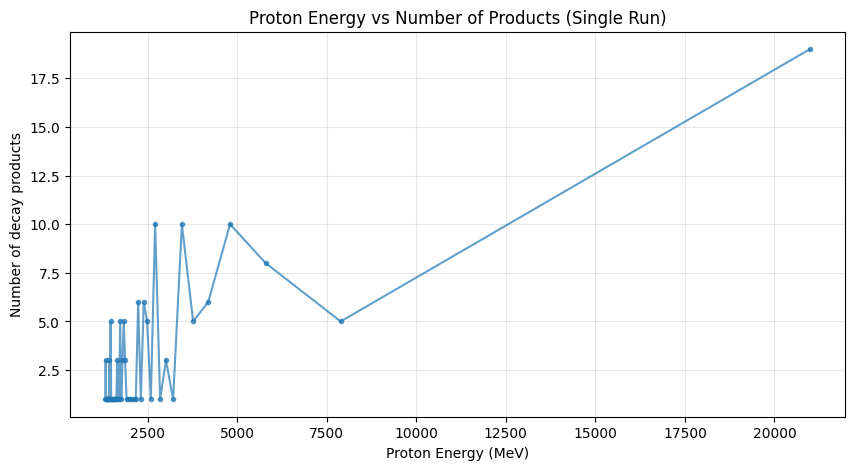

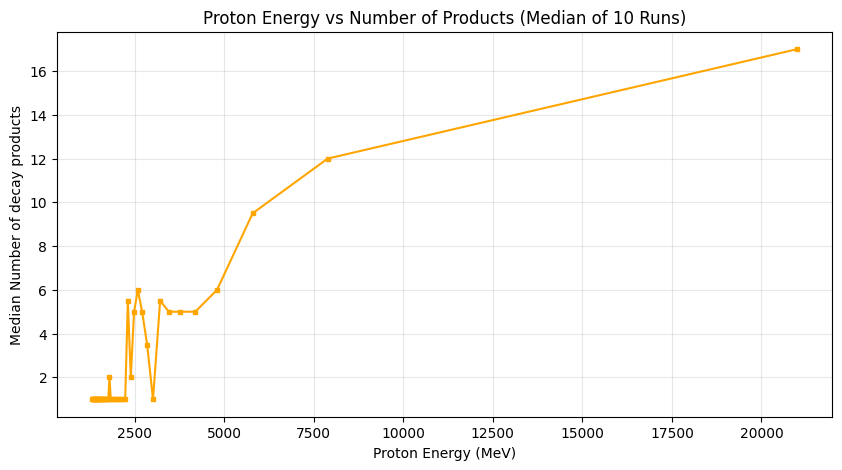

In [ ]:
# testing shower size vs proton energy
starting_height = 20*1000/3e8
starting_x = 0
y_traj = np.array([starting_height])
x_traj = np.array([starting_x])
beta_values = np.linspace(0.7, 0.999, 50)

# --- First Plot: Single Run Per Energy ---
number_of_products = []
proton_energies = []

for beta in beta_values:
    proton_px, proton_py = velocity_to_momentum(particle_mass('proton'), 0, -beta)
    proton_tuple = ('proton', proton_px, proton_py, x_traj, y_traj)
    proton_energy = np.sqrt(proton_px**2 + proton_py**2 + particle_mass('proton')**2)
    proton_energies.append(proton_energy)
    result_particles = run_cosmic_MC([proton_tuple], dt, Nsteps, attenuation=True)
    number_of_products.append(len(result_particles))

plt.figure(figsize=(10, 5))
plt.plot(proton_energies, number_of_products, 'o-', markersize=3, alpha=0.7)
plt.xlabel('Proton Energy (MeV)')
plt.ylabel('Number of decay products')
plt.title('Proton Energy vs Number of Products (Single Run)')
plt.grid(True, alpha=0.3)
plt.show()

# --- Second Plot: Median of 10 Runs Per Energy ---
number_of_products_median = []
proton_energies_median = []

for beta in beta_values:
    proton_px, proton_py = velocity_to_momentum(particle_mass('proton'), 0, -beta)
    proton_tuple = ('proton', proton_px, proton_py, x_traj, y_traj)
    proton_energy = np.sqrt(proton_px**2 + proton_py**2 + particle_mass('proton')**2)
    proton_energies_median.append(proton_energy)

    main_loop_repeats = 10
    energy_level_decay_sizes = []
    for i in range(main_loop_repeats):
        result_particles = run_cosmic_MC([proton_tuple], dt, Nsteps, attenuation=True)
        energy_level_decay_sizes.append(len(result_particles))
    number_of_products_median.append(np.median(energy_level_decay_sizes))

plt.figure(figsize=(10, 5))
plt.plot(proton_energies_median, number_of_products_median, 's-', color='orange', markersize=3)
plt.xlabel('Proton Energy (MeV)')
plt.ylabel('Median Number of decay products')
plt.title('Proton Energy vs Number of Products (Median of 10 Runs)')
plt.grid(True, alpha=0.3)
plt.show()

#gemini helped clean up the plots and make them more presentable - I did the computations

##Explanation of Proton Energy vs Number of Products

To begin this test, we first sampled a number of protons with beta values between 0.7 and 0.999.  The reasoning behind 0.7 as a starting value comes from the minimum threshold energy required for a proton interaction to happen.
We know that
$$
E_p \geq 1218\ \rm{MeV}   
$$

in order for downscattering to occur.

using relatistic energy, we get $$E = \frac{m_p}{\sqrt{1-\beta^2}} \geq 1218 \text{ MeV}$$

once we solve for beta, we see  $$\beta \geq 6.3$$

for a particle to interact within our model.

Once we have a range of beta to draw from, we can plot proton energy vs number of decay products.  We notice a lot of noise at lower energies, especially in our first plot with only one simulation run.  This is due to the nature of monte carlo simulations.  With low energies and random probabilities of decay, whether or not we get decay products is sensitive to initial conditions.  A proton at a low energy might be right at the edge of causing a shower, but it will only cause this shower sometimes.  As we get higher in energy, the probability of the proton interacting with the N-14 nucleus gets much higher, removing noise.  We were also able to remove noise by taking the median of 10 runs at a particular proton energy.  Taking the median removed outliers caused by the sensitivity of proton interaction at low energy.  

As for the increased number of products seen at higher energy, this is due to the fact that the proton is a 'product' of its own interaction.  After hitting an N-14 nucleus, the proton has a change of momentum, and loses some energy.  If the initial energy of the proton was very large, then it could still have ample energy after hitting the first N-14 nucleus to collide with another N-14 nucleus.  This causes a cascade of interactions and particle decays, increasing the number of decay products.  